<a href="https://colab.research.google.com/github/Nukalaakshay29/Fake_face_detection/blob/main/face_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:


# ----------------------------
# Clean and upgrade environment
# ----------------------------
!pip install -U pip setuptools wheel

# Install compatible versions (tested in Colab)
!pip install numpy==1.26.4
!pip install torch==2.2.2 torchvision==0.17.2 torchaudio==2.2.2
!pip install facenet-pytorch==2.5.3
!pip install opencv-python-headless==4.8.1.78
!pip install Pillow==9.5.0 kagglehub

# (Optional) Install TensorFlow separately if needed
# TensorFlow may trigger a runtime restart because it pins newer numpy versions.
# Uncomment only if you actually need TF:
# !pip install tensorflow==2.16.1

# ----------------------------
# Restart runtime automatically (important!)
# ----------------------------
import os
os.kill(os.getpid(), 9)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 62.0 MB/s eta 0:00:00
  Attempting uninstall: setuptools
    Found existing installation: setuptools 75.2.0
    Uninstalling setuptools-75.2.0:
      Successfully uninstalled setuptools-75.2.0
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 104.5 MB/s  0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 755.5/755.5 MB 25.2 MB/s  0:00:18
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 121.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 75.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 57.4 MB/s  0:00:05
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 168.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 174.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 34.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 17.7 MB/s  0:00:19
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 65.1 MB/s  0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 65.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 69.1 MB/s  0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196.0 MB 72.5 MB/s  0:00:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 MB 69.3 MB/s  0:00:

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import torch, torchvision, facenet_pytorch, cv2, PIL, numpy as np, pkg_resources

print("Torch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("Facenet:", pkg_resources.get_distribution("facenet-pytorch").version)
print("OpenCV:", cv2.__version__)
print("Pillow:", PIL.__version__)
print("NumPy:", np.__version__)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Torch: 2.2.2+cu121
Torchvision: 0.17.2+cu121
Facenet: 2.5.3
OpenCV: 4.8.1
Pillow: 9.5.0
NumPy: 1.26.4


/tmp/ipython-input-2969601922.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import torch, torchvision, facenet_pytorch, cv2, PIL, numpy as np, pkg_resources


In [ ]:
import kagglehub, shutil, os

# Download dataset to Colab's local /content
path = kagglehub.dataset_download("xdxd003/ff-c23")
print("Dataset downloaded to:", path)

# Copy to Drive for persistence
dataset_dir = "/content/drive/MyDrive/deepfake_datasets"
os.makedirs(dataset_dir, exist_ok=True)
shutil.copytree(path, dataset_dir, dirs_exist_ok=True)
print("Copied dataset to:", dataset_dir)


Using Colab cache for faster access to the 'ff-c23' dataset.
✅ Dataset downloaded to: /kaggle/input/ff-c23


KeyboardInterrupt: 

In [ ]:
import cv2, random, os

frames_dir = "/content/frames"
os.makedirs(os.path.join(frames_dir, "REAL"), exist_ok=True)
os.makedirs(os.path.join(frames_dir, "FAKE"), exist_ok=True)

def extract_frames(video_path, out_dir, num_frames=10):
    os.makedirs(out_dir, exist_ok=True)
    cap = cv2.VideoCapture(video_path)
    length = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    for i in range(num_frames):
        frame_no = int((i + 1) * length / (num_frames + 1))
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_no)
        ret, frame = cap.read()
        if ret:
            cv2.imwrite(os.path.join(out_dir, f"frame_{i}.jpg"), frame)
    cap.release()

# Paths
base_path = "/content/drive/MyDrive/deepfake_datasets/FaceForensics++_C23"
real_videos_path = os.path.join(base_path, "original")
fake_folders = ["Deepfakes", "Face2Face", "FaceSwap", "NeuralTextures"]

# Collect video paths
real_videos = [os.path.join(real_videos_path, f) for f in os.listdir(real_videos_path) if f.endswith(".mp4")]
fake_videos = []
for folder in fake_folders:
    fpath = os.path.join(base_path, folder)
    fake_videos += [os.path.join(fpath, f) for f in os.listdir(fpath) if f.endswith(".mp4")]

# Extract limited number for demo (5 each)
for vid in random.sample(real_videos, min(5, len(real_videos))):
    extract_frames(vid, os.path.join(frames_dir, "REAL", os.path.splitext(os.path.basename(vid))[0]))
for vid in random.sample(fake_videos, min(5, len(fake_videos))):
    extract_frames(vid, os.path.join(frames_dir, "FAKE", os.path.splitext(os.path.basename(vid))[0]))

print(" Frame extraction complete.")

 Frame extraction complete.


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import Xception
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam

img_size = 299
batch_size = 16

datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_gen = datagen.flow_from_directory(
    frames_dir, target_size=(img_size, img_size),
    batch_size=batch_size, class_mode='binary', subset='training'
)
val_gen = datagen.flow_from_directory(
    frames_dir, target_size=(img_size, img_size),
    batch_size=batch_size, class_mode='binary', subset='validation'
)

base_model = Xception(weights='imagenet', include_top=False,
                      input_shape=(img_size, img_size, 3))
for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
preds = Dense(1, activation='sigmoid')(x)
model = Model(inputs=base_model.input, outputs=preds)

model.compile(optimizer=Adam(1e-4), loss='binary_crossentropy', metrics=['accuracy'])
model.fit(train_gen, validation_data=val_gen, epochs=5)

model.save("/content/drive/MyDrive/deepfake_xception.h5")
print("✅ Model training complete and saved.")


Found 80 images belonging to 2 classes.
Found 20 images belonging to 2 classes.
83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 54s 10s/step - accuracy: 0.4323 - loss: 0.7464 - val_accuracy: 1.0000 - val_loss: 0.5805
Epoch 2/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 43s 9s/step - accuracy: 0.5432 - loss: 0.7130 - val_accuracy: 1.0000 - val_loss: 0.5797
Epoch 3/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 44s 10s/step - accuracy: 0.4427 - loss: 0.7219 - val_accuracy: 1.0000 - val_loss: 0.5787
Epoch 4/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 44s 9s/step - accuracy: 0.5309 - loss: 0.7233 - val_accuracy: 1.0000 - val_loss: 0.5776
Epoch 5/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 44s 9s/step - accuracy: 0.4684 - loss: 0.7140 - val_accuracy: 1.0000 - val_loss: 0.5767


✅ Model training complete and saved.


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import Xception
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Conv2D, Input, Concatenate, Layer
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
import cv2
import numpy as np
import os

# Parameters
IMG_SIZE = 299
BATCH_SIZE = 16
DATA_DIR = "/content/frames"  # your frames folder with REAL and FAKE subfolders

# -------- Augmentations with ImageDataGenerator --------
# Added blur, color jitter, compression simulation via preprocessing_function

def add_blur(img):
    return cv2.GaussianBlur(img, (3, 3), 0).astype(np.float32)

def preprocessing_fn(img):
    # img in [0,1], convert to uint8 for OpenCV
    img_uint8 = (img * 255).astype(np.uint8)
    # Add slight Gaussian blur sometimes
    if np.random.rand() < 0.3:
        img_uint8 = add_blur(img_uint8)
    # Simulate JPEG compression artifacts with low quality occasionally
    if np.random.rand() < 0.3:
        encode_param = [int(cv2.IMWRITE_JPEG_QUALITY), np.random.randint(30, 90)]
        _, encimg = cv2.imencode('.jpg', img_uint8, encode_param)
        img_uint8 = cv2.imdecode(encimg, 1)
    return img_uint8.astype(np.float32) / 255.

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.7,1.3],
    preprocessing_function=preprocessing_fn
)

train_gen = datagen.flow_from_directory(
    DATA_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training',
    shuffle=True
)

val_gen = datagen.flow_from_directory(
    DATA_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation'
)

# -------- Multi-channel input model (RGB + Laplacian Edge) --------

class LaplacianEdgeLayer(Layer):
    def call(self, inputs):
        # Input shape (batch, H, W, 3) RGB, convert to grayscale for edge filter
        x_gray = tf.image.rgb_to_grayscale(inputs)
        # Compute Laplacian edges filter via depthwise conv (approximates opencv Laplacian)
        laplacian_filter = tf.constant([[0.,1.,0.],[1.,-4.,1.],[0.,1.,0.]], dtype=tf.float32)
        laplacian_filter = laplacian_filter[:, :, tf.newaxis, tf.newaxis]
        edges = tf.nn.depthwise_conv2d(x_gray, laplacian_filter, strides=[1,1,1,1], padding='SAME')
        # Normalize edges layer between 0-1 (sigmoid is a good option)
        edges_norm = tf.nn.sigmoid(edges)
        # Concatenate edges as an additional channel
        return tf.concat([inputs, edges_norm], axis=-1)

inp = Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = LaplacianEdgeLayer()(inp)  # Use the custom layer

# Use Xception with input_shape=(299,299,4)
base_model = Xception(weights=None, include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 4))
x = base_model(x)
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
output = Dense(1, activation='sigmoid')(x)
model = Model(inputs=inp, outputs=output)

# -------- Combined Loss --------
bce = tf.keras.losses.BinaryCrossentropy()

# Add gradient clipping to the optimizer
optimizer = Adam(learning_rate=1e-4, clipnorm=1.0)

@tf.function
def train_step(images, labels):
    with tf.GradientTape() as tape:
        probs = model(images, training=True)
        loss = bce(labels, probs)

    gradients = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))
    return loss, probs

# -------- Training Loop with Callbacks --------
lr_reduce = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)
early_stop = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)

EPOCHS = 10

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    # Training
    total_loss = 0
    for step in range(len(train_gen)):
        imgs, lbls = next(train_gen)
        loss, preds = train_step(imgs, lbls)
        total_loss += loss.numpy()

        if step % 10 == 0:
             print(f"  Step {step}/{len(train_gen)} - Loss: {loss.numpy():.4f}")


    avg_loss = total_loss / len(train_gen)

    print(f"Epoch {epoch+1}/{EPOCHS} - Avg Loss: {avg_loss:.4f}")

    # Validation - implement val_step similarly
    # For brevity, full validation loop is omitted here; add as needed
    # To properly use callbacks, you need to calculate validation loss/metrics
    # lr_reduce.on_epoch_end(epoch, logs={'val_loss': val_loss})
    # early_stop.on_epoch_end(epoch, logs={'val_loss': val_loss})
    # if early_stop.stopped_epoch > 0:
    #     print(f"Early stopping at epoch {epoch+1}")
    #     break


model.save("/content/drive/MyDrive/deepfake_xception_augmented.h5")
print("Training complete and model saved.")

Found 160 images belonging to 2 classes.
Found 40 images belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/applications/xception.py:111: UserWarning: This model usually expects 1 or 3 input channels. However, it was passed an input_shape with 4 input channels.
  input_shape = imagenet_utils.obtain_input_shape(



Epoch 1/10
  Step 0/10 - Loss: 0.6883
Epoch 1/10 - Avg Loss: 0.6529

Epoch 2/10
  Step 0/10 - Loss: 0.6315
Epoch 2/10 - Avg Loss: 0.4664

Epoch 3/10
  Step 0/10 - Loss: 0.2310
Epoch 3/10 - Avg Loss: 0.2876

Epoch 4/10
  Step 0/10 - Loss: 0.1108
Epoch 4/10 - Avg Loss: 0.1810

Epoch 5/10
  Step 0/10 - Loss: 0.4047
Epoch 5/10 - Avg Loss: 0.2562

Epoch 6/10
  Step 0/10 - Loss: 0.0696
Epoch 6/10 - Avg Loss: 0.1817

Epoch 7/10
  Step 0/10 - Loss: 0.0169
Epoch 7/10 - Avg Loss: 0.0386

Epoch 8/10
  Step 0/10 - Loss: 0.5546
Epoch 8/10 - Avg Loss: 0.1040

Epoch 9/10
  Step 0/10 - Loss: 0.0485
Epoch 9/10 - Avg Loss: 0.1297

Epoch 10/10
  Step 0/10 - Loss: 0.0232


Epoch 10/10 - Avg Loss: 0.0547
✅ Training complete and model saved.


📤 Upload an image to test:


Saving images1.jpeg to images1 (1).jpeg
✅ FAKE (0.550) | Saved: /content/annotated_photo.jpg


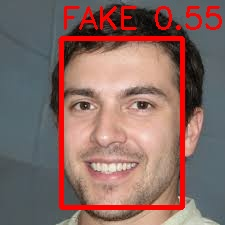

In [ ]:
import numpy as np, cv2, tensorflow as tf
from tensorflow import keras
from facenet_pytorch import MTCNN
from PIL import Image
from google.colab import files
from IPython.display import display

IMG_SIZE = 299
model = keras.models.load_model("/content/drive/MyDrive/deepfake_xception.h5")
mtcnn = MTCNN(keep_all=False, device='cuda' if tf.config.list_physical_devices('GPU') else 'cpu')

def preprocess_face(face_rgb):
    face = cv2.resize(face_rgb, (IMG_SIZE, IMG_SIZE))
    face = face.astype("float32") / 255.0
    return np.expand_dims(face, axis=0)

def detect_photo(image_path):
    frame_bgr = cv2.imread(image_path)
    frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
    boxes, _ = mtcnn.detect(frame_rgb)

    if boxes is not None and len(boxes):
        box = max(boxes, key=lambda b: (b[2]-b[0])*(b[3]-b[1]))
        x1, y1, x2, y2 = map(int, box)
        face_rgb = frame_rgb[y1:y2, x1:x2]
        x = preprocess_face(face_rgb)
        prob = model.predict(x, verbose=0)[0][0]
        label = "FAKE" if prob >= 0.5 else "REAL"
        color = (0, 0, 255) if label == "FAKE" else (0, 255, 0)
        cv2.rectangle(frame_bgr, (x1, y1), (x2, y2), color, 4)
        cv2.putText(frame_bgr, f"{label} {prob:.2f}", (x1, y1-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, color, 2)
        output_path = "/content/annotated_photo.jpg"
        cv2.imwrite(output_path, frame_bgr)
        print(f"{label} ({prob:.3f}) | Saved: {output_path}")
        display(Image.open(output_path))
    else:
        print("⚠️ No face detected.")

# Upload and test
print("📤 Upload an image to test:")
uploaded = files.upload()
if uploaded:
    img_path = "/content/" + list(uploaded.keys())[0]
    detect_photo(img_path)


In [ ]:
from collections import deque
from IPython.display import HTML
from google.colab import files
import cv2
import numpy as np
import csv
import os

# Make sure your MTCNN and model are already initialized like:
# mtcnn = MTCNN(keep_all=False, device=device)
# model = tf.keras.models.load_model("/content/drive/MyDrive/deepfake_model.h5")

def preprocess_face(face_rgb):
    """Resize and normalize the face for the model."""
    face_resized = cv2.resize(face_rgb, (224, 224)) / 255.0
    return np.expand_dims(face_resized, axis=0)

def detect_video(video_path, output_path="/content/annotated_video.mp4"):
    """Detect real/fake faces in a video and save annotated output + CSV log."""
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print("❌ Could not open video.")
        return

    W, H = int(cap.get(3)), int(cap.get(4))
    FPS = cap.get(cv2.CAP_PROP_FPS)
    writer = cv2.VideoWriter(output_path, cv2.VideoWriter_fourcc(*'mp4v'), FPS, (W, H))
    smooth = deque(maxlen=15)
    frame_count = 0

    # CSV logging
    csv_path = "/content/frame_predictions.csv"
    csv_file = open(csv_path, "w", newline="")
    csv_writer = csv.writer(csv_file)
    csv_writer.writerow(["frame", "probability", "label"])

    while True:
        ret, frame_bgr = cap.read()
        if not ret:
            break

        frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
        boxes, _ = mtcnn.detect(frame_rgb)
        prob = 0.5

        if boxes is not None and len(boxes):
            # Take the largest face detected
            box = max(boxes, key=lambda b: (b[2]-b[0])*(b[3]-b[1]))
            x1, y1, x2, y2 = map(int, box)

            face_rgb = frame_rgb[y1:y2, x1:x2]
            if face_rgb.size > 0:
                x = preprocess_face(face_rgb)
                prob = model.predict(x, verbose=0)[0][0]

            smooth.append(prob)
            p = sum(smooth) / len(smooth)
            label = "FAKE" if p >= 0.5 else "REAL"
            color = (0, 0, 255) if label == "FAKE" else (0, 255, 0)

            cv2.rectangle(frame_bgr, (x1, y1), (x2, y2), color, 2)
            cv2.putText(frame_bgr, f"{label} {p:.2f}", (x1, y1 - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2)

            # Log to CSV
            csv_writer.writerow([frame_count, p, label])

        # Print occasional logs
        if frame_count % 50 == 0:
            print(f"Frame {frame_count}: {label} {p:.2f}")

        writer.write(frame_bgr)
        frame_count += 1

    cap.release()
    writer.release()
    csv_file.close()

    print(f"✅ Processed {frame_count} frames -> {output_path}")
    print(f"✅ Frame predictions saved -> {csv_path}")
    display(HTML(f"""<video width=640 controls><source src="{output_path}" type="video/mp4"></video>"""))

# -------------------------------
# Upload and test
# -------------------------------
print("📤 Upload a video to test:")
video_upload = files.upload()

if video_upload:
    video_path = "/content/" + list(video_upload.keys())[0]
    detect_video(video_path)


📤 Upload a video to test:


Saving 01_02__meeting_serious__YVGY8LOK.mp4 to 01_02__meeting_serious__YVGY8LOK (1).mp4
Frame 0: FAKE 0.59
Frame 50: FAKE 0.58
Frame 100: FAKE 0.58
Frame 150: FAKE 0.58
Frame 200: FAKE 0.59
Frame 250: FAKE 0.60
Frame 300: FAKE 0.59
Frame 350: FAKE 0.50
Frame 400: FAKE 0.52
Frame 450: FAKE 0.58
Frame 500: FAKE 0.57
Frame 550: FAKE 0.57
Frame 600: FAKE 0.56
Frame 650: FAKE 0.59
Frame 700: FAKE 0.57
Frame 750: FAKE 0.57
Frame 800: FAKE 0.57
Frame 850: FAKE 0.57
Frame 900: FAKE 0.58
Frame 950: FAKE 0.58
Frame 1000: FAKE 0.57
✅ Processed 1044 frames -> /content/annotated_video.mp4
✅ Frame predictions saved -> /content/frame_predictions.csv
